<a href="https://colab.research.google.com/github/alisterpage/CHEM3580-Jupyter-Notebooks/blob/main/lectorials/water_MSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Water is ... Fascinating!!

Thermal fluctuations in a liquid cause a dissolved molecule to wander from its original position, executing a ‘random walk’. Eventually, the displacement of the molecule  is determined by its  **diffusion coefficient, D** (measured in area per time, e.g. m2/s). The diffusion coefficient is a proportionality constant, which relates the rate of diffusion of the molecule to that molecule's concentration gradient. Effectively, molecules and particles will move faster to a region where their concentration is lower (you know this already – drop some food colouring in water, and watch what happens!).

The **self-diffusion coefficient**, as opposed to the diffusion coefficient, specifically refers to a molecule’s diffusion relative to its own bulk motion. That is, the self-diffusion coefficient of water is the diffusion coefficient of a single water molecule diffusing through bulk water. Mills determined the self-diffusion coefficient of water to be 2.299 $\times$ 10$^{-9}$ m$^2$/s at 298 K (see the table below for the variation of this value with temperature). In terms of other solvents, water’s diffusion is similar to toluene (2.267 $\times$ 10$^{-9}$ m$^2$/s) and higher than cyclohexane (1.1470 $\times$ 10$^{-9}$ m$^2$/s). Water’s diffusion is typical of small molecules and is actually one of the few properties for which it is ***not*** unusual.

**Experimental Self-Diffusion Coefficients for Water**
| Temperature ($^\circ$ C) | D ( $\times$ 10$^{-9}$ m$^2$/s)
| --- | --- |
|1|1.149|
|4|1.276|
|5|1.313|
|15|1.777|
|25|2.299|
|35|2.919|
|45|3.575|


As we have seen in the lectures for this section of the course, the most common way to calculate D is to use Einstein's relation over long simulation times,

$$D = \frac{1}{6}\frac{\left\langle \left| \mathbf{r}_{i}(t) - \mathbf{r}_{i}(0) \right|^{2}\right\rangle}{t} $$

where $\mathbf{r}_{i}(t)$ is the position of the $i^{\text{th}}$ particle at time $t$. The quantity $\left| \mathbf{r}_{i}(t) - \mathbf{r}_{i}(0) \right|$ is the displacement that particle $i$ has moved in time $t$. The angle brackets $\left\langle \right\rangle$ indicate a time-averaged property.

If we consider the equation above carefully, we can see that by plotting the mean-squared displacement $\left\langle \left| \mathbf{r}_{i}(t) - \mathbf{r}_{i}(0) \right|^{2}\right\rangle $ as a function of time (i.e. $\left\langle \left| \mathbf{r}_{i}(t) - \mathbf{r}_{i}(0) \right|^{2}\right\rangle $ on the vertical axis, time $t$ on the horizontal axis), the diffusion coefficient $D$ can be calculated simply as **1/6 $\times$ the slope of this curve.**

In this exercise we will use the ```MDAnalysis``` python module to calculate the self-diffusion coefficient of water using the TIP3P and TIP4P-Ew water modles.

Use the MD calculator below to consider the following questions.

1. Does the TIP3P water model reproduce the self-diffusion O-O, O-H and H-H interactions in liquid water?
1. Does the TIP4P-Ew water model do any better than the TIP3P modeL? If so, why? (If not, why not?) (_HINT - consider the assumptions and terms that define these two water models_)

In [9]:
#@title Setup the Environment
!python -V
!pip install -q openmm MDAnalysis tidynamics

# install compiler
!apt-get -qq update
!apt-get -qq install -y gfortran

# remove existing directory if it exists
import os
import shutil
if os.path.exists("packmol-master"):
    print("Removing existing packmol-master directory...")
    shutil.rmtree("packmol-master")

# download latest Packmol source
!wget -q https://github.com/m3g/packmol/archive/refs/heads/master.zip
!unzip -q master.zip

# compile
%cd packmol-master
!make
%cd ..

# add to PATH

os.environ["PATH"] = "/content/packmol-master:" + os.environ["PATH"]
!which packmol

from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout
import re
import time
import numpy as np
import matplotlib.pyplot as plt

Python 3.12.13
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Removing existing packmol-master directory...
/content/packmol-master
 ------------------------------------------------------ 
 Compiling packmol with /usr/bin/gfortran 
 Flags: -O3 -march=native -funroll-loops 
 ------------------------------------------------------ 
 ------------------------------------------------------ 
 Packmol succesfully built.
 ------------------------------------------------------ 
/content
/content/packmol-master/packmol


In [2]:
#@title Choose Simulation Parameters

import ipywidgets as widgets
from IPython.display import display

#SIMULATION TEMPERATURE
# create a float text widget to input variable
temp_text = widgets.FloatText(
    value=298.0,  # default value
    description='Simulation Temperature (K):',
    step=1.0,  # step size
)
# adjust the layout of the widget
temp_text.layout.width = 'auto'
temp_text.style.description_width = 'initial'
# define a function to update the variable
def update_temp_text(change):
    global simTemperature
    simTemperature = change.new
# register the update function with the widget
temp_text.observe(update_temp_text, 'value')
# display the widget
display(temp_text)
# access the selected temperature value
simTemperature = temp_text.value*kelvin

#BOXSIZE
# create a float text widget to input variable
temp_text = widgets.FloatText(
    value=26.0,  # default value
    description='Box Size (Angstrom):',
    step=1.0,  # step size
)
# adjust the layout of the widget
temp_text.layout.width = 'auto'
temp_text.style.description_width = 'initial'
# define a function to update the variable
def update_temp_text(change):
    global boxsize
    boxsize = change.new
# register the update function with the widget
temp_text.observe(update_temp_text, 'value')
# display the widget
display(temp_text)
# access the selected temperature value
boxsize = temp_text.value

#TIMESTEP
# create a float text widget to input variable
temp_text = widgets.FloatText(
    value=1.0,  # default value
    description='Time step (fs):',
    step=0.5,  # step size
)
# adjust the layout of the widget
temp_text.layout.width = 'auto'
temp_text.style.description_width = 'initial'
# define a function to update the variable
def update_temp_text(change):
    global simTimestep
    simTimestep = change.new
# register the update function with the widget
temp_text.observe(update_temp_text, 'value')
# display the widget
display(temp_text)
# access the selected temperature value
simTimestep = temp_text.value*femtoseconds

#PRESSURE
# create a float text widget to input variable
temp_text = widgets.FloatText(
    value=1.0,  # default value
    description='Simulation pressure (atm):',
    step=0.10,  # step size
)
# adjust the layout of the widget
temp_text.layout.width = 'auto'
temp_text.style.description_width = 'initial'
# define a function to update the variable
def update_temp_text(change):
    global simPressure
    simPressure = change.new
# register the update function with the widget
temp_text.observe(update_temp_text, 'value')
# display the widget
display(temp_text)
# access the selected temperature value
simPressure = temp_text.value*atmospheres

#STEPS
# create a float text widget to input variable
temp_text = widgets.FloatText(
    value=100000,  # default value
    description='# MD steps:',
    step=100,  # step size
)
# adjust the layout of the widget
temp_text.layout.width = 'auto'
temp_text.style.description_width = 'initial'
# define a function to update the variable
def update_temp_text(change):
    global simNumSteps
    simNumSteps = change.new
# register the update function with the widget
temp_text.observe(update_temp_text, 'value')
# display the widget
display(temp_text)
# access the selected temperature value
simNumSteps = temp_text.value

#Forcefield selection
ffield_dropdown = widgets.Dropdown(
    options=['TIP3P', 'TIP4P-Ew'],
    value='TIP3P', # Default value
    description='Forcefield:',
    disabled=False,
)
ffield_dropdown.layout.width = 'auto'
ffield_dropdown.style.description_width = 'initial'

def update_ffield(change):
    global ffield
    selected_value = change.new
    if selected_value == 'TIP3P':
        ffield = 'tip3p'
    elif selected_value == 'TIP4P-Ew':
        ffield = 'tip4pew'

ffield_dropdown.observe(update_ffield, 'value')
display(ffield_dropdown)

# Set initial ffield based on the default value of the dropdown
initial_ffield_value = ffield_dropdown.value
if initial_ffield_value == 'TIP3P':
    ffield = 'tip3p'
elif initial_ffield_value == 'TIP4P-Ew':
    ffield = 'tip4pew'


FloatText(value=298.0, description='Simulation Temperature (K):', layout=Layout(width='auto'), step=1.0, style…

FloatText(value=26.0, description='Box Size (Angstrom):', layout=Layout(width='auto'), step=1.0, style=Descrip…

FloatText(value=1.0, description='Time step (fs):', layout=Layout(width='auto'), step=0.5, style=DescriptionSt…

FloatText(value=1.0, description='Simulation pressure (atm):', layout=Layout(width='auto'), step=0.1, style=De…

FloatText(value=100000.0, description='# MD steps:', layout=Layout(width='auto'), step=100.0, style=Descriptio…

Dropdown(description='Forcefield:', layout=Layout(width='auto'), options=('TIP3P', 'TIP4P-Ew'), style=Descript…

In [3]:
#@title Parameter Summary

density=0.99705
water=int(boxsize**3*density*1e6*(1e-10)**3/(18.01)*6.02214e23)
print("Box size of",boxsize,"angstroms at density,",density,"g/cm3 requires ",water," water molecules")
print(f"Simulation size: {water} waters")
print(f"Box size: {boxsize} Ang.")
print(f"Simulation temperature: {simTemperature}")
print(f"Simulation pressure: {simPressure}")
print(f"Simulation time step: {simTimestep}")
print(f"# MD steps: {simNumSteps} ; Total simulation length: {simNumSteps * simTimestep} = {simNumSteps*simTimestep / 1000 / 1000 / femtoseconds * nanoseconds}.")
print(f"Water model: {ffield}")
pdbFile = 'system.pdb'

#clean up any possible previous runs
for f in pdbFile, 'system_tip4pew.pdb', 'data.dcd', 'data.csv', 'water.pdb', 'packmol.in', 'packmol.out':
  if os.path.exists(f):
    os.remove(f)



Box size of 26.0 angstroms at density, 0.99705 g/cm3 requires  585  water molecules
Simulation size: 585 waters
Box size: 26.0 Ang.
Simulation temperature: 298.0 K
Simulation pressure: 1.0 atm
Simulation time step: 1.0 fs
# MD steps: 100000.0 ; Total simulation length: 100000.0 fs = 0.1 ns.
Water model: tip3p


In [4]:
#@title Setup the Simulation 🔨🔨🔨

with open("packmol.in", "w") as f:
    f.write("tolerance 2.0\n")
    f.write("filetype pdb\n")
    f.write("output system.pdb\n")
    f.write("\n")
    f.write("structure water.pdb\n")
    f.write("  number {0}\n".format(int(water)))
    f.write("  inside cube 2. 2. 2. {0}\n".format(boxsize))
    f.write("end structure\n")
    f.write("\n")
    f.write("pbc {0} {0} {0}\n".format(boxsize))

text = '''ATOM      1  O   HOH A   1       4.125  13.679  13.761  1.00  0.00           O
ATOM      2  H1  HOH A   1       4.025  14.428  14.348  1.00  0.00           H
ATOM      3  H2  HOH A   1       4.670  13.062  14.249  1.00  0.00           H'''

with open('water.pdb', 'w') as f:
    f.write(text)

!packmol < packmol.in > packmol.out

In [5]:
#@title Setup & Run MD Simulation 🔨🔨🔨


pdb = PDBFile('system.pdb')
forcefield = ForceField(f"{ffield}.xml")


if ffield == 'tip4pew':
  modeller = Modeller(pdb.topology, pdb.positions)
  modeller.addExtraParticles(forcefield)
  PDBFile.writeFile(modeller.topology, modeller.positions, open('system_tip4pew.pdb', 'w'))
  pdb = PDBFile('system_tip4pew.pdb','M')

system = forcefield.createSystem(
    pdb.topology,
    nonbondedMethod=PME,
    nonbondedCutoff=8*angstrom,
    constraints=HBonds,
    rigidWater=True)

system.addForce(MonteCarloBarostat(simPressure, simTemperature, 1))

integrator = LangevinMiddleIntegrator(simTemperature, 1/picosecond, simTimestep)
simulation = Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)

simulation.reporters.append(DCDReporter('data.dcd', 10))
simulation.reporters.append(StateDataReporter(
    'data.csv',
    10,
    step=True,
    temperature=True,
    potentialEnergy=True,
    kineticEnergy=True,
    totalEnergy=True,
    volume=True,
    density=True
))

print("Running Energy Minimisation:")
t0 = time.time()
simulation.minimizeEnergy()
t1 = time.time()
minTime = t1-t0
print(f"{ffield} minimisation took {minTime} seconds")

print('Running NPT Simulation')
t0 = time.time()
simulation.step(simNumSteps)
t1 = time.time()
simTime = t1-t0
print(f"{ffield} simulation took {simTime} seconds for {simNumSteps} timesteps")


Running Energy Minimisation:
tip3p minimisation took 2.7865021228790283 seconds
Running NPT Simulation
tip3p simulation took 97.50741815567017 seconds for 100000.0 timesteps


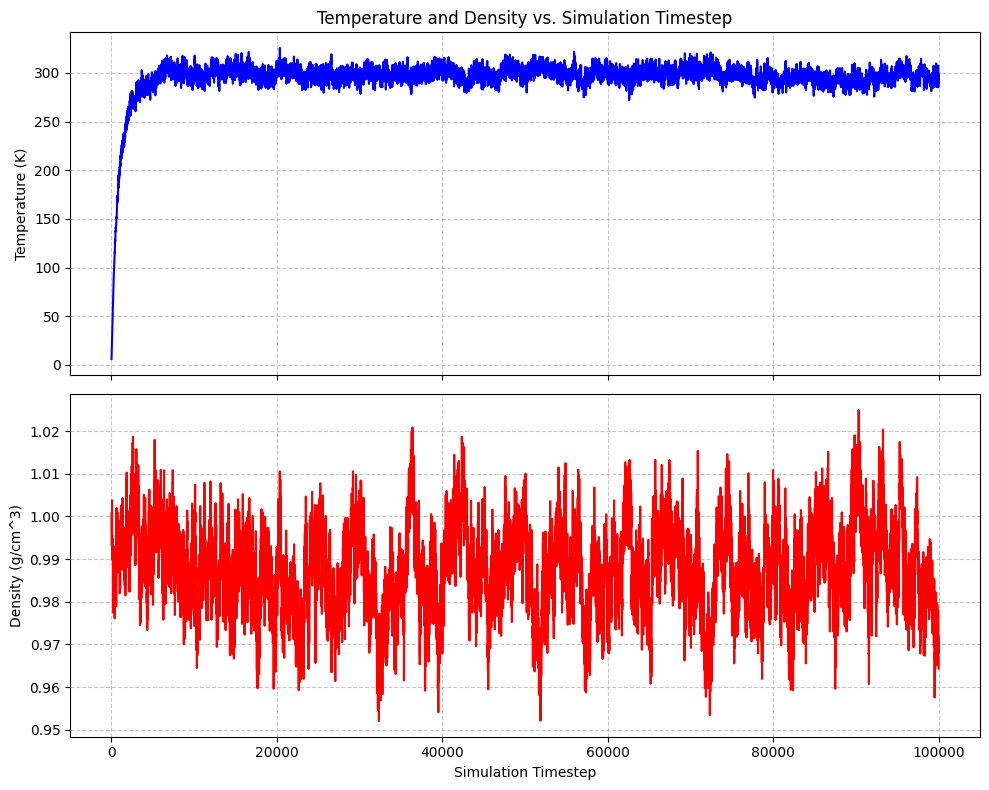

Density is 0.9875373305817823 -/- 0.010285462977561503  g/cm3
Temperature is 295.38049499811416 -/- 20.745263240220403  K


In [6]:
#@title Are we Equilibrated Yet?🧪🧪🧪


data = np.genfromtxt('data.csv', skip_header=1,delimiter=',')
steps = data[:,0]
temperature = data[:,4]
density = data[:,6]

# Create a 2x1 subplot
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Temperature vs. Timestep
axes[0].plot(steps, temperature, color='blue')
axes[0].set_ylabel('Temperature (K)')
axes[0].set_title('Temperature and Density vs. Simulation Timestep')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Density vs. Timestep
axes[1].plot(steps, density, color='red')
axes[1].set_xlabel('Simulation Timestep')
axes[1].set_ylabel('Density (g/cm^3)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

average_density=np.mean(density[-20000:])
stdev_density=np.std(density[-20000:])
print("Density is",average_density,"-/-",stdev_density," g/cm3")
average_temperature=np.mean(temperature[-20000:])
stdev_temperature=np.std(temperature[-20000:])
print("Temperature is",average_temperature,"-/-",stdev_temperature," K")

In [10]:
#@title Calculate Mean-Squared Displacements 💻

import MDAnalysis as mda
import MDAnalysis.analysis.msd as msd

# Determine the correct PDB topology file based on the forcefield selected in the parameters cell
pdb_topology_file = 'system.pdb'
if 'ffield' in globals() and ffield == 'tip4pew':
  pdb_topology_file = 'system_tip4pew.pdb'

u = mda.Universe(pdb_topology_file,'data.dcd')


MSD = msd.EinsteinMSD(u, select='name O', msd_type='xyz', fft=True)
MSD.run()

100%|██████████| 585/585 [00:05<00:00, 115.86it/s]


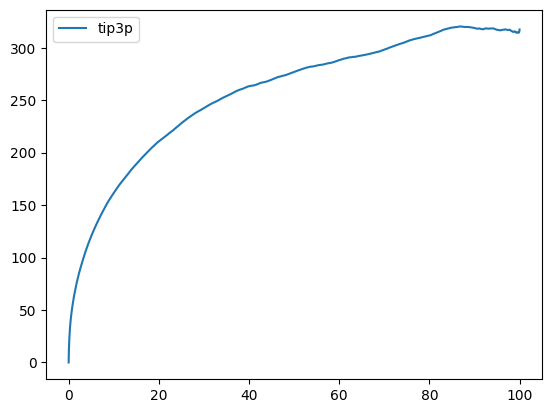

Self diffusion coefficient is 1.959741979646389e-09 m**2/s +/- 2.1806381932242377e-12 m**2/s


In [11]:
#@title Plot the MSD & Calculate Diffusion Coefficient 💻

import matplotlib.pyplot as plt


nframes = MSD.n_frames
timestep = 0.001*10 # this is the amount of real-time between MD frames in the DSD file you saved above. The time step is 0.001 ps, and the simulation is saved every 10 steps.
lagtimes = np.arange(nframes)*timestep # this is the array of times t, i.e. the horizontal axis values
msd =  MSD.results.timeseries # this is the array of MSD values, i.e. the vertical axis values
plt.plot(lagtimes,msd,label=ffield)
plt.legend()
plt.show()



from scipy.stats import linregress
start_time = 40
end_time = 80
start_index = int(start_time/timestep)
end_index = int(end_time/timestep)
linear_model = linregress(lagtimes[start_index:end_index],msd[start_index:end_index])
slope = linear_model.slope
error = linear_model.stderr
D = slope * 1/6*(1e-20)/1e-12*meter*meter/second
pm_D = error * 1/6*(1e-20)/1e-12*meter*meter/second
print("Self diffusion coefficient is",D,"+/-",pm_D)